In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os


from visual.generator.render import render_graph
from visual.generator.graphgen import graphgen
from utils.gui import vic, vis
from pathlib import Path
from visual.generator.graphgen import gg_id
from concurrent.futures import ThreadPoolExecutor
import concurrent
from time import time
from tempfile import NamedTemporaryFile
from utils.prob import choose


In [11]:


sz = 2
element = cv2.getStructuringElement(cv2.MORPH_RECT, (2 * sz + 1, 2 * sz + 1), (sz, sz))

def render(gg, conf, m_node, m_edge, idx):
    gg = nx.nx_agraph.to_agraph(gg)
    gg.graph_attr.update(conf)

    if m_node or m_edge:
        gg.edge_attr['color'] = 'white'
        gg.edge_attr['fontcolor'] = 'white'
        gg.node_attr['style'] = 'filled'
        gg.node_attr['color'] = 'white'
        gg.node_attr['fillcolor'] = 'white'
        gg.node_attr['fontcolor'] = 'white'

        if m_node:
            nis = sorted(gg.nodes())
            ni = gg.get_node(nis[idx])
            ni.attr['color'] = 'black'
            ni.attr['fillcolor'] = 'black'
            ni.attr['fontcolor'] = 'black'

        if m_edge:
            nis = sorted(gg.edges())
            ni = gg.get_edge(*nis[idx])
            ni.attr['color'] = 'black'

    gg.layout(prog='dot')

    with NamedTemporaryFile(mode='w+', suffix=".png", delete=True) as tf:
        gg.draw(tf.name)
        tf.flush()
        img = cv2.imread(tf.name)
        if m_edge or m_node:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            _, img = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            if m_edge:
                img = cv2.dilate(img, element)

    return img

def render_seg(g, g_cnf):
    n_ids, e_ids = list(range(1, 1 + len(g.nodes))), list(range(1, 1 + len(g.edges)))

    rgb_image = None

    full = render(g, g_cnf, False, False, 0)
    with ThreadPoolExecutor(max_workers=10) as ex:
        # n_imgs = np.array(list(ex.map(lambda i: render(g, g_cnf, True, False, i-1), n_ids)))
        e_imgs = np.array(list(ex.map(lambda i: render(g, g_cnf, False, True, i-1), e_ids)))
        # for idx, mask in zip(n_ids, n_imgs):
        #     if rgb_image is None: rgb_image = np.zeros((*mask.shape, 3), dtype=np.uint8)
        #     rgb_image[mask != 0] = [0, idx, 1] # bgr  (should be rgb)
        for idx, mask in zip(e_ids, e_imgs):
            if rgb_image is None: rgb_image = np.zeros((*mask.shape, 3), dtype=np.uint8)
            rgb_image[mask != 0] = [0, idx, 1]

    return full, rgb_image

# vic(full, rgb_image[:,:,1], cmap='turbo')

In [7]:
ds_path = Path("/home/petr/study/diploma/dataset_seg")


In [16]:
from utils.utils import pmap


def ds_one(_):
    g_cnf = dict(
        splines=choose(
            2, "curved",
            3, "ortho",
            # 2, "true",
            1, "polyline",
            # 1, "line"
        ),
        dpi=100,
        bgcolor='white'
    )
    g = nx.DiGraph()
    graphgen(g)
    full, seg = render_seg(g, g_cnf)

    i = gg_id()
    cv2.imwrite(str(ds_path / "image" / f"{i}.png"), full)
    cv2.imwrite(str(ds_path / "annotation" / f"{i}.png"), seg)


os.makedirs(ds_path / "image", exist_ok=True)
os.makedirs(ds_path / "annotation", exist_ok=True)
for i in os.listdir(ds_path / "image"):
    os.unlink(ds_path / "image" / i)
for i in os.listdir(ds_path / "annotation"):
    os.unlink(ds_path / "annotation" / i)

_ = pmap(ds_one, range(800), max_workers=5)

  0%|          | 0/800 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from datasets import Image as DatasetImage
from PIL import Image

label2id = {
    "background": 0,
    # "node": 1,
    "edge": 1,
}

ids = os.listdir(ds_path / "annotation")[:100]
train_ids, test_ids = train_test_split(ids, train_size=0.7, test_size=0.3)

def loadi(x, is_ann):
    return Image.open(ds_path / ("annotation" if is_ann else "image") / x)

train_split = {
    "image": [loadi(i, 0) for i in train_ids],
    "annotation": [loadi(i, 1) for i in train_ids],
}
validation_split = {
    "image": [loadi(i, 0) for i in test_ids],
    "annotation": [loadi(i, 1) for i in test_ids],
}

def make_dataset(**splits):
    dataset_dict = {}
    for split_name, split in splits.items():
        split["semantic_class_to_id"] = [label2id] * len(split["image"])
        dataset_split = (
            Dataset.from_dict(split)
            .cast_column("image", DatasetImage())
            .cast_column("annotation", DatasetImage())
        )
        dataset_dict[split_name] = dataset_split
    return DatasetDict(dataset_dict)

dataset = make_dataset(train=train_split, validation=validation_split)
dataset.push_to_hub("bardinpetr/diagrams-eo-seg-synth-100")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/bardinpetr/diagrams-eo-seg-synth-100/commit/8691dde51e82011f307049634968151669e09fa3', commit_message='Upload dataset', commit_description='', oid='8691dde51e82011f307049634968151669e09fa3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/bardinpetr/diagrams-eo-seg-synth-100', endpoint='https://huggingface.co', repo_type='dataset', repo_id='bardinpetr/diagrams-eo-seg-synth-100'), pr_revision=None, pr_num=None)

In [13]:
from huggingface_hub import notebook_login
notebook_login()

yolo

In [17]:
import numpy as np
from PIL import Image
from pathlib import Path
import cv2
from sklearn.model_selection import train_test_split
import shutil
from tqdm import tqdm

def convert_to_yolo_segmentation(
    input_dir: str,
    output_dir: str,
    train_ratio: float = 0.8,
    seed: int = 42
):
    input_path = Path(input_dir)
    output_path = Path(output_dir)

    annotation_dir = input_path / "annotation"
    image_dir = input_path / "image"

    annotation_files = sorted(list(annotation_dir.glob("*.png")))

    train_files, val_files = train_test_split(
        annotation_files,
        train_size=train_ratio,
        random_state=seed
    )

    for split, files in [("train", train_files), ("val", val_files)]:
        (output_path / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_path / "labels" / split).mkdir(parents=True, exist_ok=True)

        for ann_file in tqdm(files):
            file_id = ann_file.stem
            img_file = image_dir / f"{file_id}.png"

            if not img_file.exists():
                continue

            ann_img = np.array(Image.open(ann_file))
            r_channel = ann_img[:, :, 0]
            g_channel = ann_img[:, :, 1]

            height, width = ann_img.shape[:2]

            shutil.copy(img_file, output_path / "images" / split / f"{file_id}.png")

            label_lines = []

            unique_classes = np.unique(r_channel)
            unique_classes = unique_classes[unique_classes > 0]

            for class_id in unique_classes:
                class_mask = (r_channel == class_id)
                unique_instances = np.unique(g_channel[class_mask])

                for instance_id in unique_instances:
                    if instance_id == 0:
                        continue

                    instance_mask = class_mask & (g_channel == instance_id)
                    instance_mask_uint8 = instance_mask.astype(np.uint8) * 255

                    contours, _ = cv2.findContours(
                        instance_mask_uint8,
                        cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE
                    )

                    for contour in contours:
                        if len(contour) < 3:
                            continue

                        contour = contour.squeeze()
                        if contour.ndim == 1:
                            continue

                        normalized_contour = contour.astype(float)
                        normalized_contour[:, 0] /= width
                        normalized_contour[:, 1] /= height

                        normalized_contour = np.clip(normalized_contour, 0, 1)

                        coords_str = " ".join(
                            f"{x:.6f} {y:.6f}"
                            for x, y in normalized_contour
                        )

                        label_lines.append(f"{class_id - 1} {coords_str}")

            label_file = output_path / "labels" / split / f"{file_id}.txt"
            with open(label_file, "w") as f:
                f.write("\n".join(label_lines))

convert_to_yolo_segmentation("/home/petr/study/diploma/dataset_seg", "/home/petr/study/diploma/dataset_seg_yolo")

100%|██████████| 107/107 [00:02<00:00, 40.42it/s]


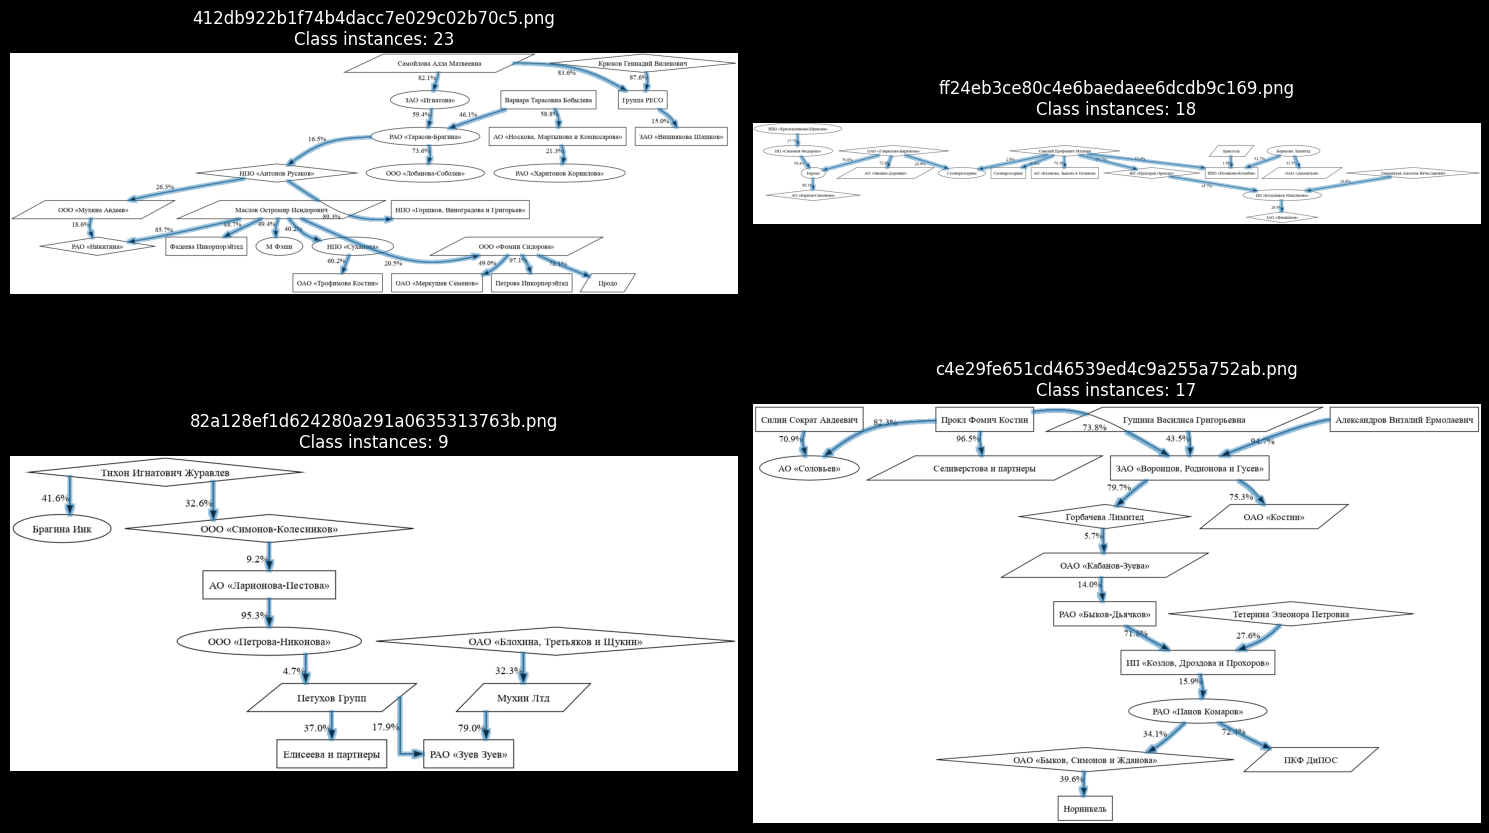

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import random

def visualize_yolo_sample(
    dataset_dir: str,
    split: str = "train",
    num_samples: int = 4,
    figsize: tuple = (15, 10),
    seed: int = None
):
    dataset_path = Path(dataset_dir)
    images_dir = dataset_path / "images" / split
    labels_dir = dataset_path / "labels" / split

    image_files = list(images_dir.glob("*.png"))

    if seed is not None:
        random.seed(seed)

    sample_files = random.sample(image_files, min(num_samples, len(image_files)))

    cols = 2
    rows = (len(sample_files) + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)

    axes = axes.flatten()

    colors = plt.cm.tab20(np.linspace(0, 1, 20))

    for idx, img_file in enumerate(sample_files):
        ax = axes[idx]

        img = Image.open(img_file)
        height, width = img.size[1], img.size[0]

        ax.imshow(img)

        label_file = labels_dir / f"{img_file.stem}.txt"

        if label_file.exists():
            with open(label_file, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue

                class_id = int(parts[0])
                coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)

                coords_abs = coords * np.array([width, height])

                color = colors[class_id % len(colors)]

                polygon = Polygon(
                    coords_abs,
                    fill=True,
                    alpha=0.4,
                    facecolor=color,
                    edgecolor=color,
                    linewidth=2
                )
                ax.add_patch(polygon)

        ax.set_title(f"{img_file.name}\nClass instances: {len(lines) if label_file.exists() else 0}")
        ax.axis('off')

    for idx in range(len(sample_files), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

visualize_yolo_sample("/home/petr/study/diploma/dataset_seg_yolo")